In [2]:
import pandas as pd
comments = pd.read_csv('stemmed_all.csv')
data = comments.loc[:,['post_id','created_at','username','text']]
data_partial = data[(data['created_at'] > '2025-10-01') & (data['created_at'] < '2025-11-01')].copy()

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix
import numpy as np

data_partial['processed_text'] = data_partial['text'].apply(lambda tokens: " ".join(tokens))
data_partial = data_partial[data_partial['processed_text'].str.strip() != ""]
vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    ngram_range=(1,1),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

vectors = vectorizer.fit_transform(data_partial['processed_text'])
feature_names = vectorizer.get_feature_names_out()
vectors_dense = vectors.toarray()
max_values_per_document = np.max(vectors_dense, axis=1)
thresholds = 0.5 * max_values_per_document
thresholds_reshaped = thresholds.reshape(-1, 1)
vectors_grounded = np.where(vectors_dense < thresholds_reshaped, 0, vectors_dense)
vectors_grounded_sparse = csr_matrix(vectors_grounded)

d:\Kuliah\PA\pdam-scraper\scrape_instagram\venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Linkage shape: (1176, 4), Samples: 1177
max_k 100

Optimal K Results:
• WCSS Curvature: 27
• Silhouette Max: 2


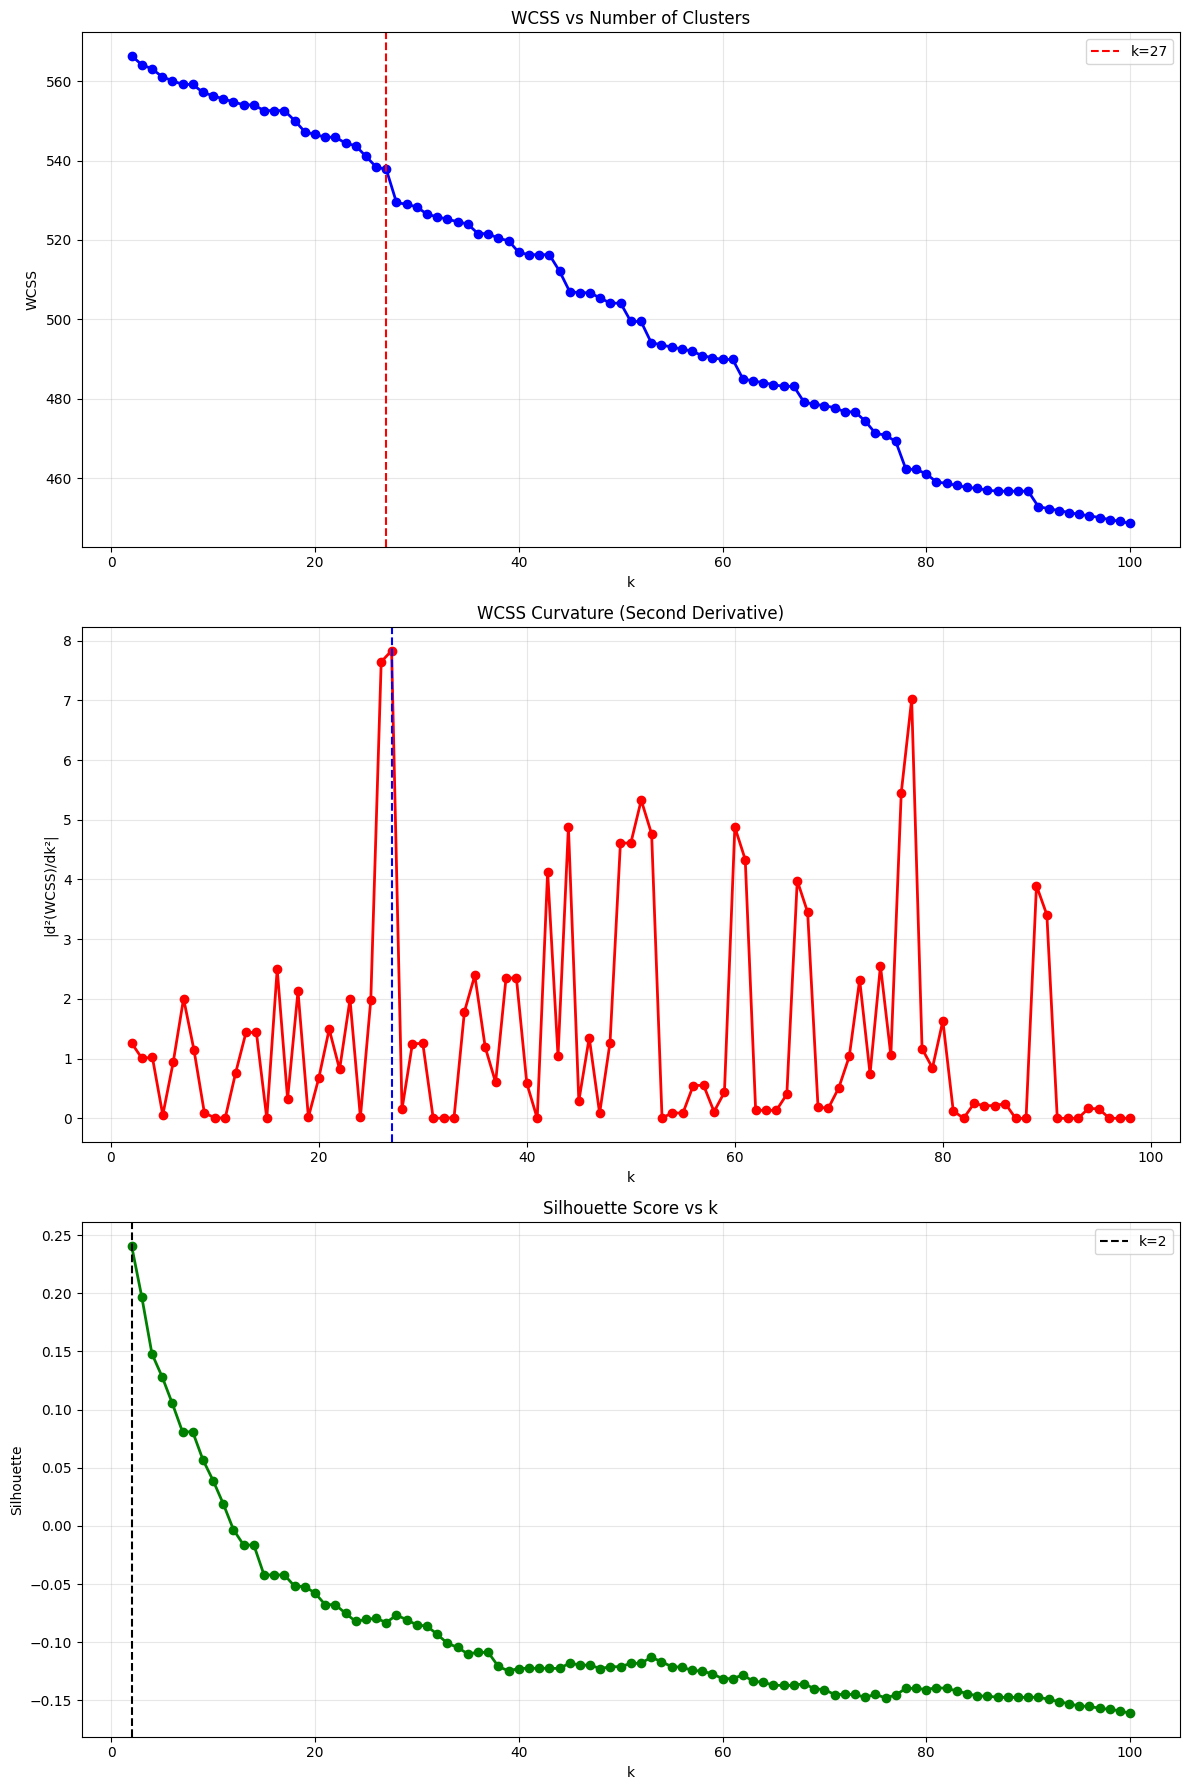

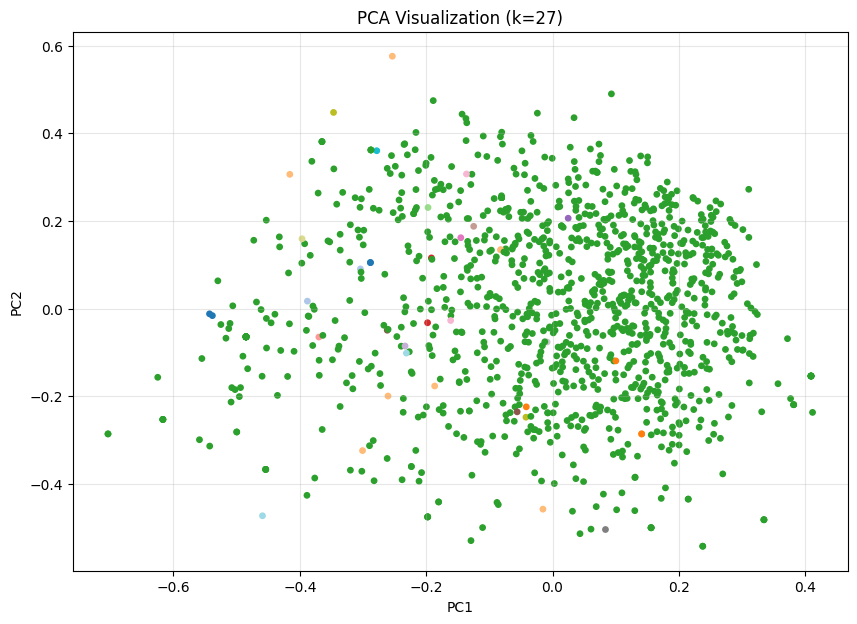

In [4]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
Z = linkage(vectors_dense, method='centroid', metric='euclidean')
Z_grounded = linkage(vectors_grounded, method='centroid', metric='euclidean')
n_samples = vectors_dense.shape[0]
print(f"Linkage shape: {Z.shape}, Samples: {n_samples}")

MIN_SAMPLES_PER_CLUSTER = 20
max_k = 100
print("max_k", max_k)
k_list = list(range(max_k, 1, -1))

wcss, sil = [], []

for k in k_list:
    # labels = fcluster(Z, t=k, criterion='maxclust')
    labels = fcluster(Z_grounded, t=k, criterion='maxclust')
    
    # Wcss
    total_var = 0.0
    for cid in np.unique(labels):
        # pts = vectors_dense[labels == cid]
        pts = vectors_grounded[labels == cid]
        if pts.shape[0] <= 1:
            continue
        cent = pts.mean(axis=0)
        total_var += np.sum(np.linalg.norm(pts - cent, axis=1)**2)
    wcss.append(total_var)
    
    # Sil
    if len(np.unique(labels)) >= 2:
        # sc = silhouette_score(vectors_dense, labels, metric='euclidean')
        sc = silhouette_score(vectors_grounded, labels, metric='euclidean')
    else:
        sc = np.nan
    sil.append(sc)

wcss, sil = np.array(wcss), np.array(sil)

# cobacob dl
# WCSS Curve
first = np.diff(wcss)
second = np.diff(first)
idx_curv = np.nanargmax(np.abs(second))
k_curv = k_list[idx_curv + 2]

# Silhouette Max
valid_idx = np.where(~np.isnan(sil))[0]
k_sil = k_list[valid_idx[np.nanargmax(sil[valid_idx])]] if len(valid_idx) else None

print(f"\nOptimal K Results:")
print(f"• WCSS Curvature: {k_curv}")
print(f"• Silhouette Max: {k_sil}")


fig, axes = plt.subplots(3, 1, figsize=(12, 18))
# Within cluster sum of squaress plt
axes[0].plot(k_list, wcss, 'bo-', linewidth=2)
axes[0].axvline(k_curv, color='red', linestyle='--', label=f"k={k_curv}")
axes[0].set_title("WCSS vs Number of Clusters")
axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS")
axes[0].grid(alpha=0.3); axes[0].legend()

# Curve plt
axes[1].plot(k_list[2:], np.abs(second), 'ro-', linewidth=2)
axes[1].axvline(k_curv, color='blue', linestyle='--')
axes[1].set_title("WCSS Curvature (Second Derivative)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("|d²(WCSS)/dk²|")
axes[1].grid(alpha=0.3)

# # Silhouette plt
axes[2].plot(k_list, sil, 'go-', linewidth=2)
if k_sil:
    axes[2].axvline(k_sil, color='black', linestyle='--', label=f"k={k_sil}")
axes[2].set_title("Silhouette Score vs k")
axes[2].set_xlabel("k"); axes[2].set_ylabel("Silhouette")
axes[2].grid(alpha=0.3); axes[2].legend()

plt.tight_layout()
plt.show()

# PCA Vis
k_optimal = k_curv
labels_opt = fcluster(Z_grounded, t=k_optimal, criterion='maxclust')
# labels_opt = fcluster(Z, t=k_optimal, criterion='maxclust')

pca = PCA(n_components=2)
# vec2d = pca.fit_transform(vectors_dense)
vec2d = pca.fit_transform(vectors_grounded)

plt.figure(figsize=(10, 7))
plt.scatter(vec2d[:,0], vec2d[:,1], c=labels_opt, cmap='tab20', s=15)
plt.title(f"PCA Visualization (k={k_optimal})")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()